In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
orders = pd.read_csv('orders.csv')
users = pd.read_csv('users.csv')   
restaurants = pd.read_csv('restaurants.csv')
complaints = pd.read_csv('complaints.csv')

In [76]:
print('Orders shape      :', orders.shape)
print('Users shape       :', users.shape)
print('Restaurants shape :', restaurants.shape)
print('Complaints shape  :', complaints.shape)

Orders shape      : (250000, 11)
Users shape       : (30000, 5)
Restaurants shape : (10000, 6)
Complaints shape  : (18564, 5)


In [77]:
#skipping neg order values 
orders = orders[orders['order_value'] >= 0].copy()

In [78]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   restaurant_id          10000 non-null  object 
 1   city                   10000 non-null  object 
 2   cuisine                10000 non-null  object 
 3   avg_rating             10000 non-null  float64
 4   onboarding_date        10000 non-null  object 
 5   commission_percentage  10000 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 468.9+ KB


In [79]:
#Null delivery time -> replace with avg delivery time
avg_delivery_time = orders['delivery_time_minutes'].mean()
orders['delivery_time_minutes'].fillna(avg_delivery_time, inplace=True)


C:\Users\Dell\AppData\Local\Temp\ipykernel_21208\3203622898.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders['delivery_time_minutes'].fillna(avg_delivery_time, inplace=True)


In [80]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
users['signup_date'] = pd.to_datetime(users['signup_date'])

In [91]:
df['month']=df['order_date'].dt.to_period('M')

In [92]:
#merge orders with restaurants
df = orders.merge(restaurants[['restaurant_id', 'commission_percentage', 'city']], on='restaurant_id', 
how='left')
# Merge orders  with Users
df = df.merge(users[['user_id', 'acquisition_channel']], 
              on='user_id', 
              how='left')



In [93]:
df['commission_rate']=df['commission_percentage']/100

In [94]:
# Net Revenue: (order value * commission %) + delivery fees - discount
df['commission_revenue'] = df['order_value'] * df['commission_rate']
df['net_revenue'] = df['commission_revenue'] + df['delivery_fee'] - df['discount_applied']


In [95]:
df.loc[df['is_cancelled'] == 1, 'net_revenue'] = 0

In [96]:

print(df.head())


  order_id user_id restaurant_id order_date  order_value  discount_applied  \
0   O00000   U9780         R9317 2025-10-09   582.414641         91.600007   
1   O00001  U29975         R5542 2025-12-18   704.533701        104.764976   
2   O00002  U18213         R2727 2025-12-13   452.134223        110.158568   
3   O00003   U8363         R4250 2025-10-13   435.612854         46.527398   
4   O00004  U22419         R7336 2025-10-20   521.636338        165.636448   

   delivery_fee  delivery_time_minutes  is_cancelled payment_type     city_x  \
0            40              15.000000             1         Card  Bangalore   
1            30              52.568285             0          COD  Hyderabad   
2            30              46.071049             0          COD  Hyderabad   
3            30              60.739708             0          UPI    Kolkata   
4            20              23.548674             0         Card    Chennai   

   commission_percentage     city_y acquisition_ch

In [100]:
df['month']=df['order_date'].dt.to_period('M')

In [101]:
months = df['Month'].sort_values().unique()
start_month = months[0]
end_month = months[-1]

print(f"Comparing {start_month} vs {end_month}")


Comparing 2025-10 vs 2025-12


In [102]:
def get_monthly_metrics(month_data):
    total_revenue = month_data['net_revenue'].sum()
    total_orders = len(month_data)
    # AOV 
    aov = month_data['order_value'].mean() 
    # Avg discount per order
    avg_discount = month_data['discount_applied'].mean()
    # Cancellation Rate
    cancel_rate = (month_data['is_cancelled'] == 1).mean()
    
    return total_revenue, total_orders, aov, avg_discount, cancel_rate

# Get metrics
m1_data = df[df['month'] == start_month]
m3_data = df[df['month'] == end_month]

rev_m1, ord_m1, aov_m1, disc_m1, cancel_m1 = get_monthly_metrics(m1_data)
rev_m3, ord_m3, aov_m3, disc_m3, cancel_m3 = get_monthly_metrics(m3_data)


In [103]:
#  Impact of Change in AOV
avg_comm_rate = df['commission_rate'].mean()
impact_aov = (aov_m3 - aov_m1) * ord_m1 * avg_comm_rate


In [104]:
# Impact of Increase in Discount Intensity
impact_discount = -(disc_m3 - disc_m1) * ord_m3


In [105]:
#  Impact of Cancellations

rev_per_order_m1 = rev_m1 / ord_m1
impact_cancellation = -(cancel_m3 - cancel_m1) * ord_m3 * rev_per_order_m1


In [57]:
print(f"Total Revenue Change: {rev_m3 - rev_m1:.2f}")
print(f"1.  Impact of AOV Change: {impact_aov:.2f}")
print(f"2.  Impact of Discount Increases: {impact_discount:.2f}")
print(f"3.  Impact of Cancellation Spike: {impact_cancellation:.2f}")


Total Revenue Change: -920859.20
1.  Impact of AOV Change: -584587.84
2.  Impact of Discount Increases: -276328.58
3.  Impact of Cancellation Spike: -3701.14


In [70]:
print(orders.columns.tolist())

['order_id', 'user_id', 'restaurant_id', 'order_date', 'order_value', 'discount_applied', 'delivery_fee', 'delivery_time_minutes', 'is_cancelled', 'payment_type', 'city']


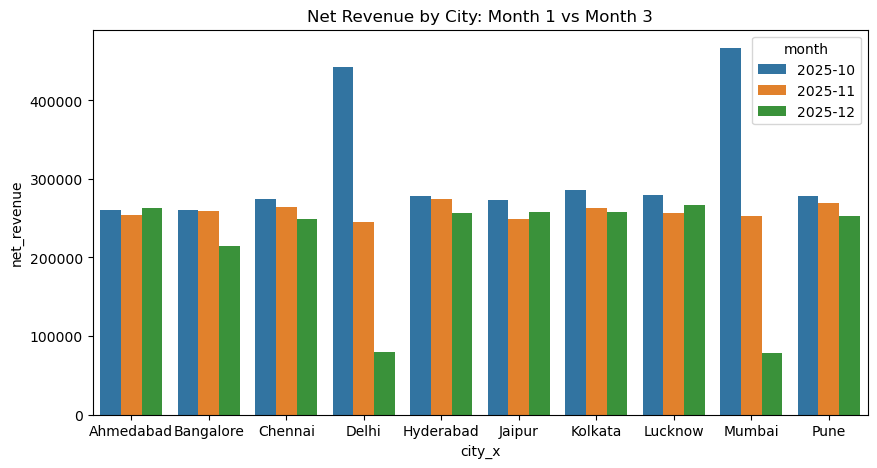

In [107]:
city_mix = df.groupby(['month','city_x'])['net_revenue'].sum().reset_index()
# Calculate percentage share manually or plot
plt.figure(figsize=(10, 5))
sns.barplot(data=city_mix, x='city_x', y='net_revenue', hue='month')
plt.title("Net Revenue by City: Month 1 vs Month 3") 
plt.show()

In [144]:
#complaint type most correlated with cancellations 
ord_ct = orders.merge(
    complaints[["order_id","complaint_type","resolution_time_hours"]],
    on="order_id", how="left"
)
result = ord_ct.groupby("complaint_type").agg(
    count        = ("order_id",             "count"),
    cancel_rate  = ("is_cancelled",         "mean"),
    avg_res_hrs  = ("resolution_time_hours","mean")
).sort_values("cancel_rate", ascending=False).round(3)
print(result)

                      count  cancel_rate  avg_res_hrs
complaint_type                                       
Refund Not Processed   3760        0.798       25.665
App Issue              2808        0.688       25.368
Late Delivery          5564        0.148       25.571
Food Quality           2875        0.131       25.159
Missing Item            805        0.002       26.118
Wrong Item             1309        0.002       25.250
Payment Failure        1303        0.000       25.531


In [153]:
#relationship between delivery time and complaint probability 
ord_c = orders.copy()
ord_c["has_complaint"] = ord_c["order_id"].isin(complaints["order_id"]).astype(int)

# Bucket delivery times
ord_c["bucket"] = pd.cut(
    ord_c["delivery_time_minutes"],
    bins=[0, 30, 45, 60, 90],
    labels=["<30min","30-45min","45-60min",">60min"]
)

result = ord_c.groupby("bucket").agg(
    count          = ("order_id",       "count"),
    complaint_rate = ("has_complaint",  "mean"),
    cancel_rate    = ("is_cancelled",   "mean")
).round(4)
print(result)

C:\Users\Dell\AppData\Local\Temp\ipykernel_21208\2411483577.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = ord_c.groupby("bucket").agg(


          count  complaint_rate  cancel_rate
bucket                                      
<30min    62201          0.0507       0.1205
30-45min  94976          0.0523       0.1205
45-60min  68291          0.0512       0.1186
>60min    22532          0.3021       0.1202
